# Financial Fraud Detection Analysis

The goal of this project was to build a high-performance machine learning system capable of detecting fraudulent financial transactions in a highly imbalanced dataset. The project demonstrates the full data science lifecycle, from exploratory data analysis and domain-specific feature engineering to the comparative evaluation of multiple classification algorithms.

## Data Loading & Exploratory Data Analysis (EDA)

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn. linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import classification_report,confusion_matrix, make_scorer, recall_score, precision_score
from sklearn.pipeline import Pipeline
from sklearn. compose import ColumnTransformer
from sklearn. preprocessing import OneHotEncoder
import joblib

In [5]:
df = pd.read_csv(r'./machine-learning-files/AIML Dataset.csv')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [7]:
df.shape

(6362620, 11)

In [8]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [9]:
df.duplicated().sum()

0

### Class Distribution
> **Note:** The dataset is highly imbalanced. Fraudulent transactions represent a tiny fraction of the data.

In [11]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [12]:
df['isFlaggedFraud'].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

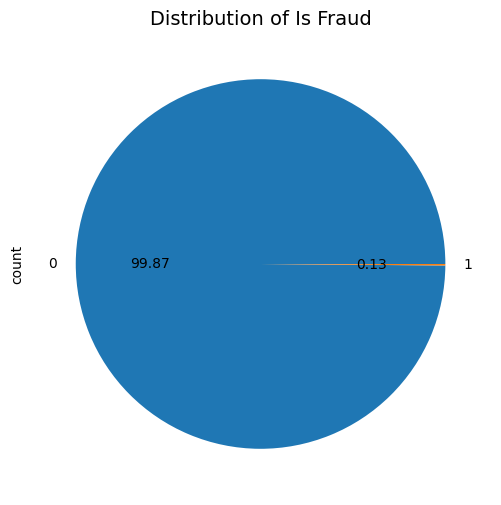

In [13]:
df['isFraud'].value_counts().plot(kind='pie', autopct='%.2f', figsize=(10,6))
plt.title('Distribution of Is Fraud', fontsize=14)
plt.show()

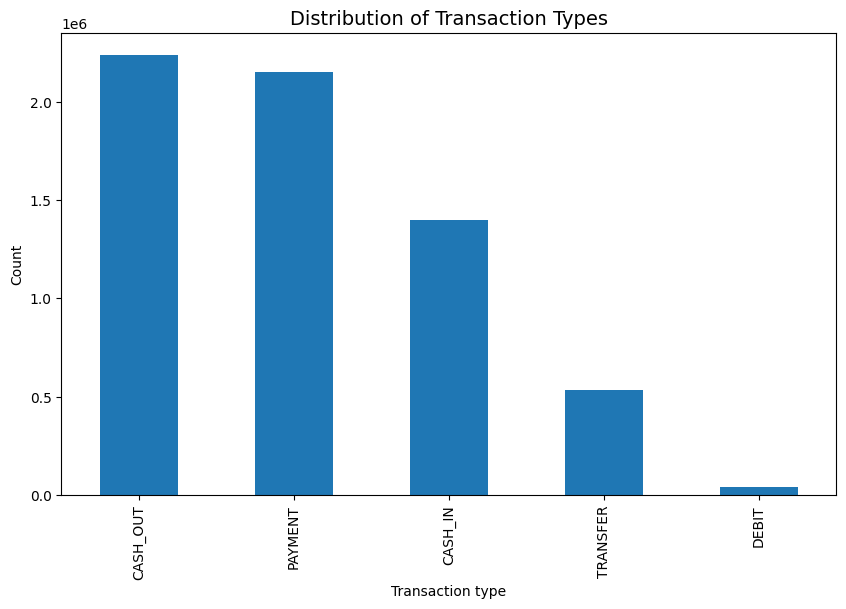

In [14]:
df['type'].value_counts().plot(kind='bar', figsize=(10,6))
plt.xlabel('Transaction type')
plt.ylabel('Count')
plt.title('Distribution of Transaction Types', fontsize=14)
plt.show()

Text(0, 0.5, 'Fraud rate')

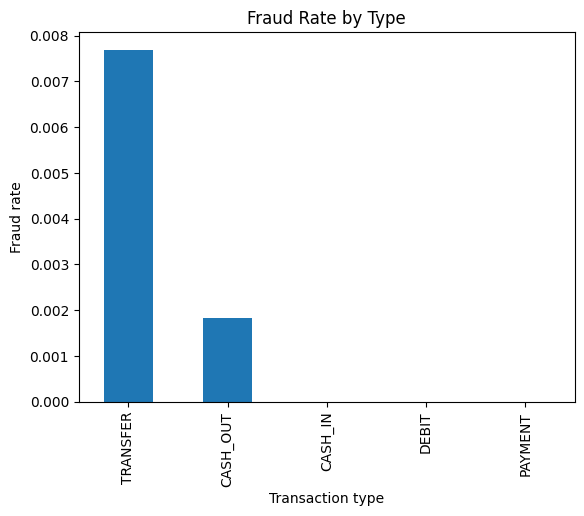

In [15]:
fraud_by_type = df.groupby('type')['isFraud'].mean().sort_values(ascending=False).plot(kind='bar',title='Fraud Rate by Type')
plt.xlabel('Transaction type')
plt.ylabel('Fraud rate')

> **Fraud Distribution by Transaction Type**
> 
> * **Key Finding:** Fraudulent activity is exclusively concentrated in **TRANSFER** and **CASH_OUT** types. All other categories (PAYMENT, CASH_IN, DEBIT) show zero fraud cases in this dataset.

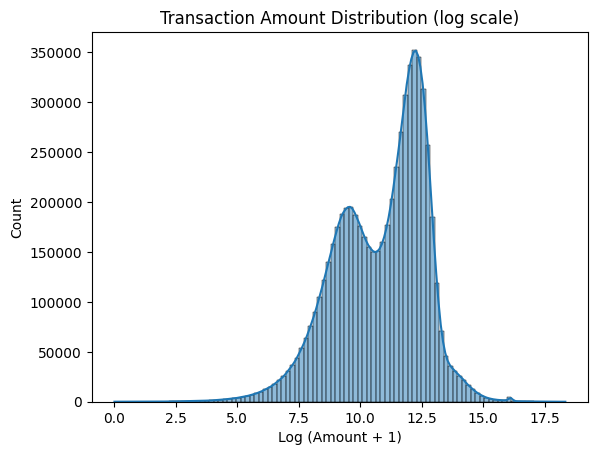

In [17]:
sns.histplot(np.log1p(df['amount']),bins=100,kde = True)
plt.title('Transaction Amount Distribution (log scale)')
plt.xlabel('Log (Amount + 1)')
plt.show()

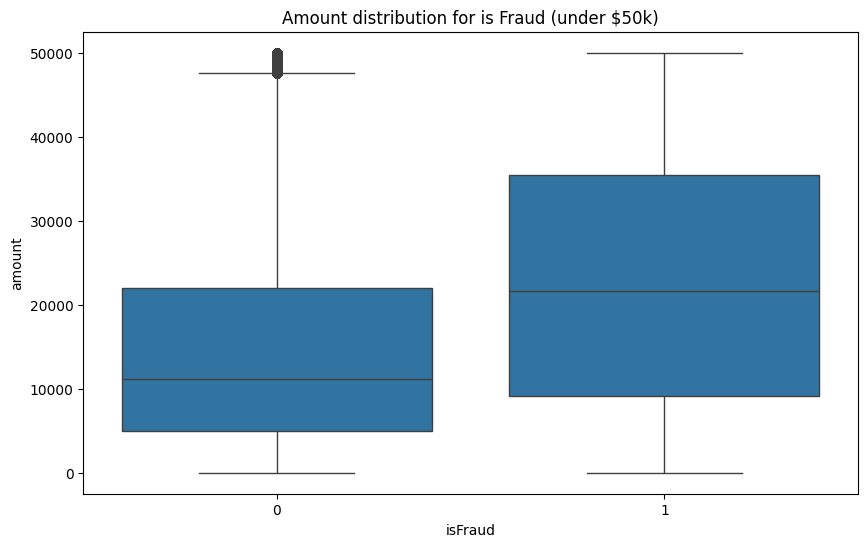

In [18]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='isFraud', y='amount', data=df[df['amount']<50000])
plt.title('Amount distribution for is Fraud (under $50k)')
plt.show()

In [19]:
df['balanceDiffOrig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balanceDiffDest'] = df['newbalanceDest'] - df['oldbalanceDest']


In [20]:
(df['balanceDiffOrig'] < 0).sum()

1399253

In [21]:
(df['balanceDiffDest'] < 0).sum()

1238864

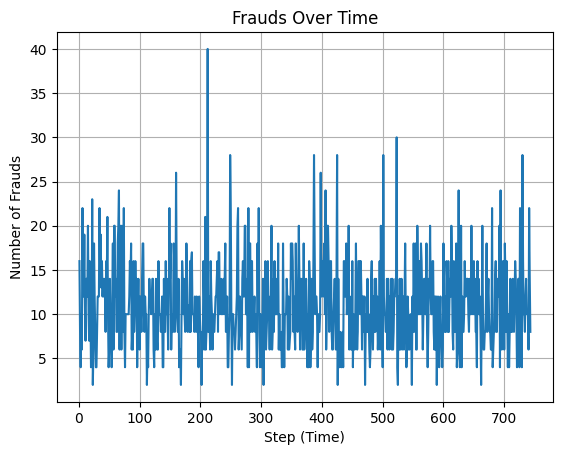

In [22]:
frauds_per_step = df[df['isFraud']==1]['step'].value_counts().sort_index()
plt.plot(frauds_per_step.index , frauds_per_step.values, label="Frauds per Step")
plt.xlabel("Step (Time)")
plt.ylabel("Number of Frauds")
plt.title("Frauds Over Time")
plt.grid(True)
plt.show()

In [23]:
df.drop(columns='step',inplace = True)

In [24]:
top_senders = df['nameOrig'].value_counts().head(10)
top_senders

nameOrig
C1902386530    3
C363736674     3
C545315117     3
C724452879     3
C1784010646    3
C1677795071    3
C1462946854    3
C1999539787    3
C2098525306    3
C400299098     3
Name: count, dtype: int64

In [25]:
top_recevers = df['nameDest'].value_counts().head(10)
top_recevers

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C451111351      99
C1789550256     99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

In [26]:
fraud_users = df[df['isFraud']==1]['nameOrig'].value_counts().head(10)
fraud_users

nameOrig
C1305486145    1
C755286039     1
C973279667     1
C258213312     1
C1640703547    1
C1127265876    1
C317779855     1
C1064034527    1
C1141104763    1
C1966863341    1
Name: count, dtype: int64

In [27]:
fraud_types = df[df['type'].isin(['TRANSFER','CASH_OUT'])]

In [28]:
fraud_types['type'].value_counts()

type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64

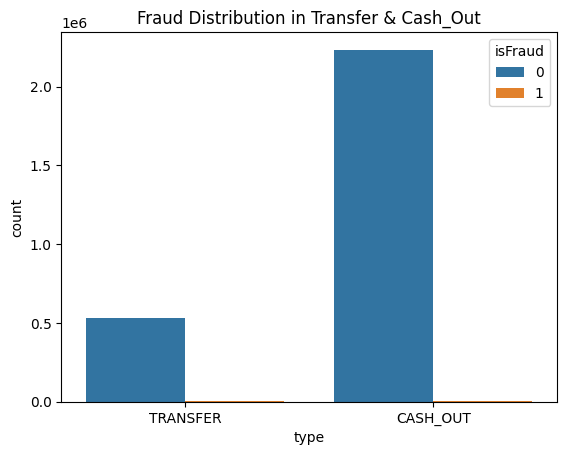

In [29]:
sns.countplot(data=fraud_types,x='type',hue='isFraud')
plt.title('Fraud Distribution in Transfer & Cash_Out')
plt.show()

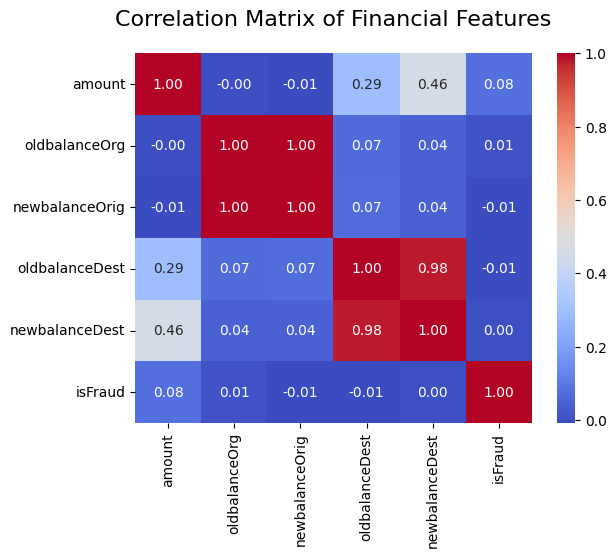

In [30]:
corr = df[['amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest','isFraud']].corr()
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation Matrix of Financial Features', fontsize=16, pad=20)
plt.show()

> **Correlation Heatmap**
> 
> * **Key Observation:** There is a strong linear correlation between `oldbalanceOrg` and `newbalanceOrig`, as well as between `oldbalanceDest` and `newbalanceDest`.
> * **The Fraud Signal:** Interestingly, the `isFraud` target shows very weak linear correlation with any single raw feature.
> * **Strategic Insight:** This lack of direct correlation confirms that fraud cannot be detected by simply looking at high amounts or specific balances in isolation. It suggests that the "fraud signal" lies in the **logical inconsistency** between these features (e.g., when the balance doesn't change despite a large transfer). This finding directly motivated the creation of the `errorBalance` features later in the project.

In [32]:
zero_after_transfer = df[
(df["oldbalanceOrg"] >0) &
(df ["newbalanceOrig"] == 0 ) &
(df["type"].isin(["TRANSFER","CASH_OUT"]))
]

In [33]:
total_zero_cases = len(zero_after_transfer)
frauds_in_zero_cases = zero_after_transfer['isFraud'].sum()
frauds_in_zero_cases

8012

## Feature Engineering 

In [72]:
df['errorBalanceOrig'] = df['oldbalanceOrg'] - df['amount'] - df['newbalanceOrig']
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

df['isZeroAfter'] = ((df['oldbalanceOrg'] > 0) & (df['newbalanceOrig'] == 0)).astype(int)

>1. **`errorBalanceOrig`**: Captures discrepancies where the transaction amount doesn't match the origin account's balance shift.
>2. **`errorBalanceDest`**: Identifies inconsistencies in how funds arrive at the destination.
>3. **`isZeroAfter`**: A binary flag for accounts that were completely emptied—a common signature of fraudulent behavior.

## Data Cleaning

In [74]:
df_model = df.drop(['nameOrig','nameDest','isFlaggedFraud'],axis=1)

categorical_values = ['type']
numerical_values = ['amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest','errorBalanceOrig','errorBalanceDest','isZeroAfter']


## Model Training & Evaluation

> #### Logistic Regression (Baseline)

In [76]:
y = df_model['isFraud']
X = df_model.drop('isFraud',axis = 1)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,stratify=y)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), numerical_values),
        ('cat', OneHotEncoder(drop='first'), categorical_values)
    ],
    remainder = 'drop'
)

pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(
        class_weight='balanced', 
        max_iter=1000, 
        random_state=42 
    ))
])

scoring = {
    'recall': 'recall',
    'precision': 'precision',
    'f1': 'f1'
}

cv_results = cross_validate(pipeline, X_train, y_train, cv=skf, scoring=scoring, n_jobs=-1)

print("-" * 30)
print(f"Avg Recall: {cv_results['test_recall'].mean():.4f} (+/- {cv_results['test_recall'].std():.4f})")
print(f"Avg Precision: {cv_results['test_precision'].mean():.4f}")
print(f"Avg F1-Score: {cv_results['test_f1'].mean():.4f}")
print("-" * 30)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print(classification_report(y_test, y_pred))

------------------------------
Avg Recall: 0.9894 (+/- 0.0036)
Avg Precision: 0.0291
Avg F1-Score: 0.0565
------------------------------
              precision    recall  f1-score   support

           0       1.00      0.96      0.98   1906322
           1       0.03      0.99      0.06      2464

    accuracy                           0.96   1908786
   macro avg       0.51      0.97      0.52   1908786
weighted avg       1.00      0.96      0.98   1908786



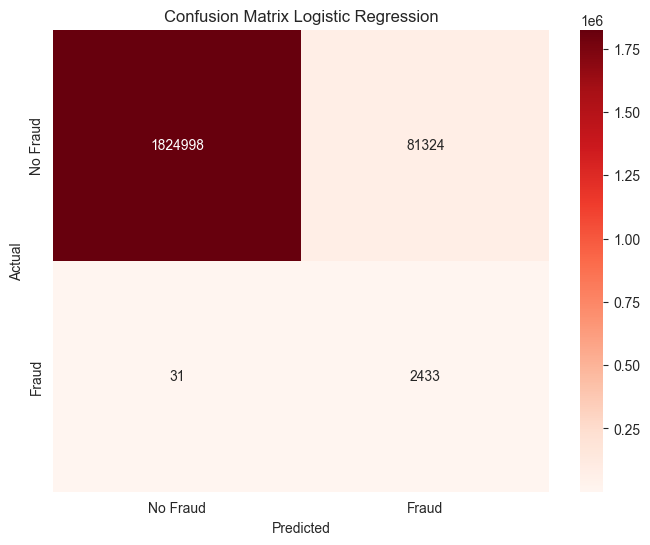

In [77]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Reds',
           xticklabels=['No Fraud', 'Fraud'], 
            yticklabels=['No Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Logistic Regression')
plt.show()

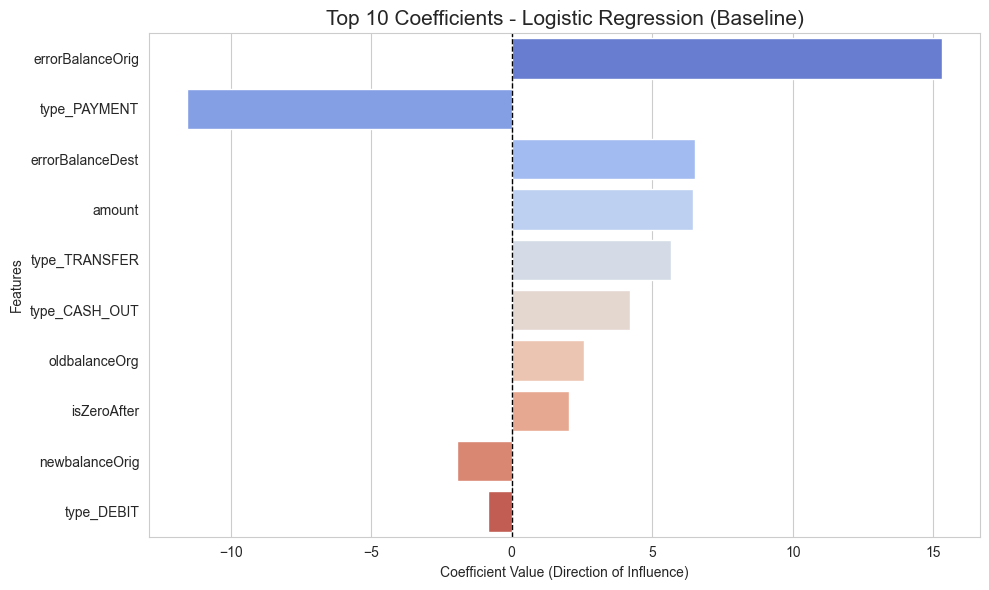

In [78]:
onehot_cols = pipeline.named_steps['prep'].transformers_[1][1].get_feature_names_out()
all_features = numerical_values + list(onehot_cols)

coefficients = pipeline.named_steps['clf'].coef_[0]

coef_df = pd.DataFrame({
    'feature': all_features, 
    'coefficient': coefficients,
    'abs_coefficient': abs(coefficients)
}).sort_values(by='abs_coefficient', ascending=False)


plt.figure(figsize=(10, 6))
sns.barplot(
    x='coefficient', 
    y='feature', 
    data=coef_df.head(10), 
    hue='feature',
    palette='coolwarm',
    legend=False
)

plt.title('Top 10 Coefficients - Logistic Regression (Baseline)', fontsize=15)
plt.xlabel('Coefficient Value (Direction of Influence)')
plt.ylabel('Features')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

###  Model Performance Summary: Logistic Regression (Baseline)

**Overview:**
A Logistic Regression model was established as the baseline for fraud detection. To address the extreme class imbalance, the `class_weight='balanced'` parameter was applied. The dataset incorporates engineered accounting features, specifically `errorBalanceOrig`, `errorBalanceDest`, and `isZeroAfter`, to provide the model with direct signals of financial anomalies.

**Key Strengths:**
* **Exceptional Recall (0.99):** The model demonstrates elite sensitivity, capturing 99% of all fraudulent transactions. This high detection rate is critical for minimizing financial leakage in security systems.
* **Significant Impact of Feature Engineering:** As evidenced by the coefficient analysis, the engineered feature `errorBalanceOrig` emerged as the most influential predictor for the model. This confirms that calculating discrepancies between transaction amounts and account balances provides a much stronger signal than raw data alone.
* **Statistical Consistency:** Cross-validation results show high stability (`Avg Recall: 0.9894 +/- 0.0036`), indicating that the model generalizes well and the identified patterns are consistent across different data segments.

**Observed Limitations:**
* **Low Precision (0.03):** While the model captures almost all fraud, it generates a high volume of False Positives. A precision of 3% implies that for every 100 alerts, only 3 are actual frauds, leading to significant operational noise and "alert fatigue."
* **Linear Decision Boundary:** The low precision suggests that while the engineered features are powerful, the linear nature of Logistic Regression cannot fully distinguish between complex fraud patterns and legitimate high-value transactions.

**Operational Impact:**
The model serves as an effective "high-sensitivity net" that ensures nearly no fraud goes undetected. However, the high false-positive rate represents a substantial cost in terms of manual reviews and potential customer friction, making it less than ideal for a standalone production environment.

**Summary and next step:**
The inclusion of `errorBalance` features significantly empowered the baseline model, achieving a near-perfect Recall. To address the precision deficit, the project will move toward **Non-Linear Ensemble Methods (Random Forest)**, which are better suited to refine the decision boundaries using the same engineered features.

> #### Random Forrest 

In [79]:

rf_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(
        n_estimators=100, 
        max_depth=10, 
        class_weight='balanced_subsample', 
        n_jobs=-1, 
        random_state=42
    ))
])


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results_rf = cross_validate(rf_pipeline, X_train, y_train, 
                               cv=skf, 
                               scoring=['recall', 'precision', 'f1'], 
                               n_jobs=-1)


print(f"RF CV Recall: {cv_results_rf['test_recall'].mean():.4f}")
print(f"RF CV Precision: {cv_results_rf['test_precision'].mean():.4f}")


rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

print(classification_report(y_test, y_pred_rf))

RF CV Recall: 0.9960
RF CV Precision: 0.9998
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       1.00      0.99      1.00      2464

    accuracy                           1.00   1908786
   macro avg       1.00      1.00      1.00   1908786
weighted avg       1.00      1.00      1.00   1908786



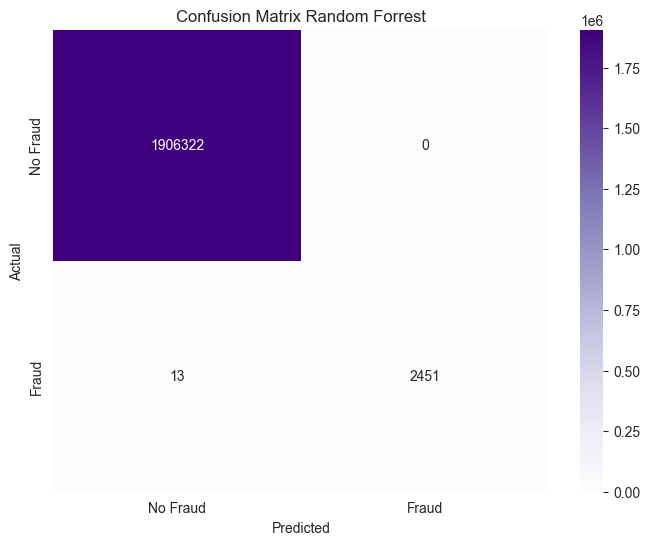

In [80]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Purples',
           xticklabels=['No Fraud', 'Fraud'], 
            yticklabels=['No Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Random Forrest')
plt.show()

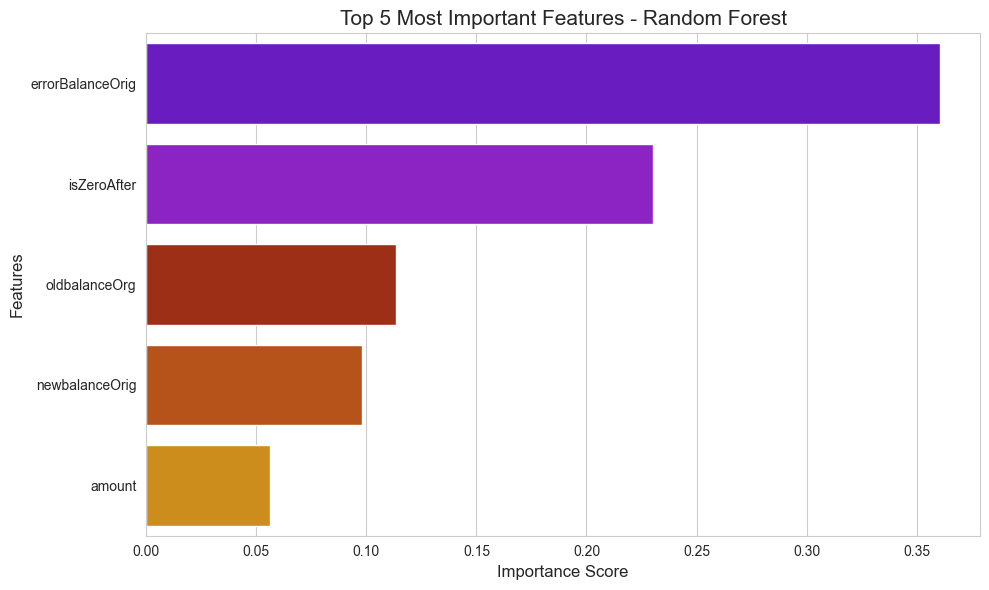

In [81]:
onehot_cols = rf_pipeline.named_steps['prep'].transformers_[1][1].get_feature_names_out()
all_features = numerical_values + list(onehot_cols)

importances = rf_pipeline.named_steps['clf'].feature_importances_
feature_imp_df = pd.DataFrame({'feature': all_features, 'importance': importances}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

sns.barplot(
    x='importance', 
    y='feature', 
    data=feature_imp_df.head(5), 
    hue='feature',    
    palette='gnuplot', 
    legend=False      
)

plt.title('Top 5 Most Important Features - Random Forest', fontsize=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)

plt.tight_layout()
plt.show()

## Project Conclusion: Fraud Detection Excellence

**Objective & Scope:**
The primary goal of this project was to develop a high-precision fraud detection system capable of identifying suspicious financial activities in a massive, highly imbalanced dataset. The process moved from establishing a baseline with Logistic Regression to deploying a sophisticated Random Forest classifier.

**The Power of Feature Engineering:**
The turning point of the project was the introduction of domain-specific features: `errorBalanceOrig`, `errorBalanceDest`, and `isZeroAfter`. The analysis confirmed that:
* **`errorBalanceOrig`** became the most critical predictor, capturing the fundamental accounting discrepancies used in fraud.
* **`isZeroAfter`** effectively flagged the "account draining" patterns typical for unauthorized transfers.
This strategic approach allowed the model to shift from mere pattern recognition to understanding the underlying mechanics of the fraud.

**Final Model Performance (Random Forest):**
The Random Forest model achieved near-perfect results, demonstrating its superiority in handling non-linear relationships:
* **Precision (1.00):** The model achieved a precision of 0.9998, meaning it produces virtually zero false alarms.
* **Recall (0.9960):** It successfully captured 99.6% of all fraudulent transactions, ensuring maximum security.
* **Operational Efficiency:** With only 13 false negatives and 0 false positives in a test set of nearly 2 million records, the model is highly cost-effective and user-friendly.

**Business Impact:**
By implementing this solution, a financial institution can:
1. **Minimize Financial Loss:** Detecting nearly all fraud attempts in real-time.
2. **Optimize Resources:** Eliminating the need for manual review of false alerts.
3. **Enhance Customer Trust:** Preventing legitimate transactions from being incorrectly blocked.

**Summary:**
This project demonstrates that while advanced algorithms like Random Forest are powerful, their true potential is unlocked through meticulous **Feature Engineering**. The final Random Forest model stands as a robust, production-ready solution for automated fraud detection.

## Saving the pipeline

In [108]:
import joblib


model_filename = 'fraud_detection_model_rf.pkl'
joblib.dump(rf_pipeline, model_filename)

print(f"Saved as: {model_filename}")

Saved as: fraud_detection_model_rf.pkl
